# Asynchroner OPC UA Factory-Server (nur Datenmodell)

In diesem Notebook bauen wir einen **asynchronen OPC UA-Server** mit
`asyncua` (opcua-asyncio), der ein Datenmodell für eine kleine Fabrik bereitstellt:

- bis zu **50 Maschinen** (jede mit `Temperature`, `State`, `Busy`),
- einen **Maintenance/Jobs**-Teilbaum (`<Maschine>_RepairNeeded`-Flags),
- einen **Orders**-Teilbaum, in dem dynamisch bis zu **200 Aufträge** angelegt werden können.

Dieses Notebook ist **Schritt 1: Asynchroner OPC UA-Server** im Multi-Agenten/OPC-UA-Beispiel.
Client-seitige Agenten (Maschinen, Wartung, Aufträge) werden in späteren Notebooks ergänzt.


## 1. Installation

Wir verwenden das Paket `asyncua` (auch bekannt als *opcua-asyncio*) für einen asynchronen OPC UA-Server.

Führen Sie die folgende Zelle einmalig in Ihrer Umgebung aus:


In [ ]:
#!pip install asyncua

## 2. Konstanten und Imports

Wir legen globale Grenzwerte fest und importieren die benötigten Module.


In [ ]:
import asyncio
import logging
from dataclasses import dataclass
from typing import Dict

from asyncua import Server, ua

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("factory-server")

MAX_MACHINES = 50
MAX_ORDERS = 200

FACTORY_NS_URI = "http://ostfalia.de/ipt/factory"

## 3. OPC UA-Datenmodell

Der Server stellt die folgende Struktur unterhalb des Standard-Knotens `Objects` bereit:

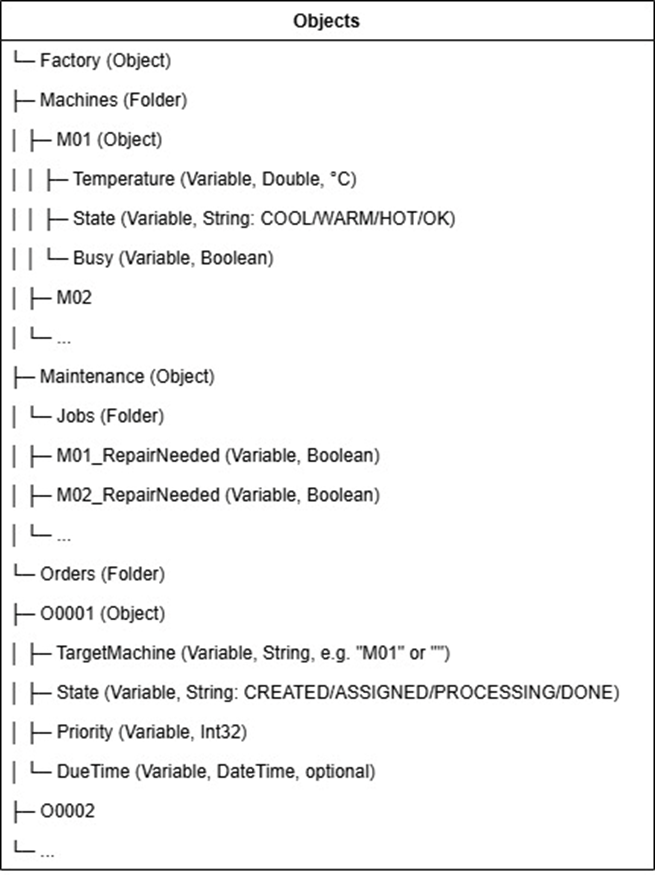


In [ ]:
@dataclass
class FactoryOpcUaServer:
    """Asynchroner OPC UA-Server, der ein Fabrik-Datenmodell bereitstellt."""

    endpoint: str = "opc.tcp://localhost:4840/freeopcua/server/"

    def __post_init__(self):
        self.server: Server = Server()
        self.nsidx: int | None = None
        self.objects = None
        self.factory = None
        self.machines_folder = None
        self.maintenance = None
        self.jobs_folder = None
        self.orders_folder = None
        self.machines: Dict[str, object] = {}
        self.jobs: Dict[str, object] = {}
        self.early_warnings: Dict[str, object] = {}
        self.orders: Dict[str, object] = {}
        self._order_counter: int = 0

    async def init(self, num_machines: int = 10):
        """Server initialisieren und Basisknoten anlegen."""
        if num_machines > MAX_MACHINES:
            raise ValueError(f"num_machines darf {MAX_MACHINES} nicht überschreiten")

        await self.server.init()
        self.server.set_endpoint(self.endpoint)
        self.server.set_server_name("Asynchroner Fabrik OPC UA-Server")

        self.nsidx = await self.server.register_namespace(FACTORY_NS_URI)
        logger.info("Namespace '%s' mit Index %s registriert", FACTORY_NS_URI, self.nsidx)

        self.objects = self.server.nodes.objects
        self.factory = await self.objects.add_object(self.nsidx, "Factory")
        self.machines_folder = await self.factory.add_folder(self.nsidx, "Machines")
        self.maintenance = await self.factory.add_object(self.nsidx, "Maintenance")
        self.jobs_folder = await self.maintenance.add_folder(self.nsidx, "Jobs")
        self.orders_folder = await self.factory.add_folder(self.nsidx, "Orders")

        for i in range(1, num_machines + 1):
            name = f"M{i:02d}"
            await self._add_machine_with_job(name)

    async def _add_machine_with_job(self, machine_name: str):
        m_obj = await self.machines_folder.add_object(self.nsidx, machine_name)

        temp = await m_obj.add_variable(
            self.nsidx,
            "Temperature",
            20.0,
            ua.VariantType.Double,
        )
        state = await m_obj.add_variable(
            self.nsidx,
            "State",
            "OK",
            ua.VariantType.String,
        )
        busy = await m_obj.add_variable(
            self.nsidx,
            "Busy",
            False,
            ua.VariantType.Boolean,
        )

        await temp.set_writable()
        await state.set_writable()
        await busy.set_writable()

        self.machines[machine_name] = m_obj

        job_var = await self.jobs_folder.add_variable(
            self.nsidx,
            f"{machine_name}_RepairNeeded",
            False,
            ua.VariantType.Boolean,
        )
        await job_var.set_writable()
        self.jobs[machine_name] = job_var

        early_warning_var = await self.jobs_folder.add_variable(
            self.nsidx,
            f"{machine_name}_EarlyWarning",
            False,
            ua.VariantType.Boolean,
        )
        await early_warning_var.set_writable()
        self.early_warnings[machine_name] = early_warning_var

    async def create_order(
        self,
        target_machine: str = "",
        priority: int = 0,
        state: str = "CREATED",
    ):
        if self._order_counter >= MAX_ORDERS:
            raise RuntimeError("Maximale Anzahl an Aufträgen erreicht")

        self._order_counter += 1
        order_id = f"O{self._order_counter:04d}"
        logger.info("Erstelle Auftrag %s (Ziel=%s, Priorität=%s)", order_id, target_machine, priority)

        order_obj = await self.orders_folder.add_object(self.nsidx, order_id)

        target_var = await order_obj.add_variable(
            self.nsidx,
            "TargetMachine",
            target_machine,
            ua.VariantType.String,
        )
        state_var = await order_obj.add_variable(
            self.nsidx,
            "State",
            state,
            ua.VariantType.String,
        )
        priority_var = await order_obj.add_variable(
            self.nsidx,
            "Priority",
            priority,
            ua.VariantType.Int32,
        )
        due_var = await order_obj.add_variable(
            self.nsidx,
            "DueTime",
            ua.Variant(None, ua.VariantType.DateTime),
        )

        for var in (target_var, state_var, priority_var, due_var):
            await var.set_writable()

        self.orders[order_id] = order_obj
        return order_obj

    async def run(self):
        logger.info("Starte asynchronen Fabrik OPC UA-Server unter %s", self.endpoint)
        async with self.server:
            while True:
                await asyncio.sleep(1)

## 5. Server starten und erste Aufträge anlegen

Die folgende Zelle:

1. Erstellt eine `FactoryOpcUaServer`-Instanz,
2. Initialisiert sie mit (beispielsweise) 20 Maschinen,
3. Legt einige Beispielaufträge an,
4. Startet die Server-Schleife.

⚠️ **Hinweis:** Diese Zelle blockiert, solange der Server läuft.
Stoppe den Kernel oder unterbreche die Zelle, um den Server zu beenden.


In [ ]:
import logging

logging.basicConfig(level=logging.WARNING)

# Oder gezielt nur den asyncua-Adressraum-Logger ruhigstellen:
logging.getLogger("asyncua.server.address_space").setLevel(logging.WARNING)

async def main():
    factory_server = FactoryOpcUaServer()
    await factory_server.init(num_machines=20)
    await factory_server.create_order(target_machine="M01", priority=10)
    await factory_server.create_order(target_machine="M05", priority=5)
    await factory_server.create_order(target_machine="", priority=1)
    await factory_server.run()

loop = asyncio.get_event_loop()
loop.create_task(main())

print("Asynchroner Fabrik OPC UA-Server im Hintergrund gestartet.")
print("Zum Stoppen: Ctrl+C / Kernel → Interrupt / Neustart.")